# **Movies Recommender System**
Student name: Colleta Kiilu

# **Executive Summary**


- The digital ecosystem

# **Business Understanding**
- Providing viewers with personalized content recommendations that suit their preferences is an essential issue for movie streaming services. This problem may cause users to become frustrated, interact less, and eventually cost the platform money.
- A movie recommendation system that makes use of user ratings and preferences can be put into place to solve this problem and greatly improve the viewing experience.
- The system can effectively recommend movies that align with users' preferences by utilizing data-driven insights, which raises the possibility of user engagement and happiness.
- The deployment of such a system has significant business advantages, such as higher conversion rates, better customer satisfaction, and improved user retention.


# **Project Objectives**
- The main objective of this project is to build a model that provides top 5 movie recommendations to a user, based on their ratings of other movies.
- Specifically, the aim of the model is to:
1. **Increase user engagement**
  - Based on users' past viewing habits and interests, the model will tailor suggestions to keep viewers engaged for longer periods and increase their likelihood of returning to the site
2. **Maximize diversity in recommendations**
  - A model that strikes a balance between familiarity and exploration so that films that suit users' preferences are recommended as well as exposing users to new suggestions.
3. **Improve content discoverability**
  - Increased user engagement by showcasing a broader selection of films, including hidden gems from its extensive library.
  


# **Importing the relevant libraries**

In [ ]:
pip install surprise

In [ ]:
import requests
import zipfile
import io

import pandas as pd
import matplotlib.pyplot as plt
%matplotlib inline
import seaborn as sns
import numpy as np
from wordcloud import WordCloud

from scipy.sparse import csr_matrix

from sklearn.decomposition import TruncatedSVD
from sklearn.model_selection import train_test_split, GridSearchCV
from sklearn.metrics import mean_squared_error, mean_absolute_error, precision_score, recall_score, f1_score
from sklearn.neighbors import NearestNeighbors

from surprise import Dataset, Reader, accuracy, dump
from surprise import SVD, SVDpp, KNNBasic, KNNBaseline
from surprise.model_selection import cross_validate, GridSearchCV, train_test_split

import warnings
warnings.filterwarnings('ignore')

# **Data Understanding**
- This section will help to explore the data to understand its size, features/columns, data types, statistical summary, as well as deal with missing values and duplicates.

## **Loading the Datasets**

In [ ]:
# movielens URL for the zipped file
url = "https://files.grouplens.org/datasets/movielens/ml-latest-small.zip"

try:
    response = requests.get(url, stream=True)
    response.raise_for_status()

    z = zipfile.ZipFile(io.BytesIO(response.content))
    z.extractall("/content/data")
    print("Data extracted successfully to /content/data")
except requests.exceptions.RequestException as e:
    print(f"Error downloading the file: {e}")
except zipfile.BadZipFile:
    print("Error: Invalid zip file")
except Exception as e:
    print(f"An unexpected error occurred: {e}")


Data extracted successfully to /content/data


In [ ]:
movies_df = pd.read_csv('/content/data/ml-latest-small/movies.csv')
movies_df.head()

,movieId,title,genres
0,1,Toy Story (1995),Adventure|Animation|Children|Comedy|Fantasy
1,2,Jumanji (1995),Adventure|Children|Fantasy
2,3,Grumpier Old Men (1995),Comedy|Romance
3,4,Waiting to Exhale (1995),Comedy|Drama|Romance
4,5,Father of the Bride Part II (1995),Comedy


In [ ]:
ratings_df = pd.read_csv('/content/data/ml-latest-small/ratings.csv')
ratings_df.head()

,userId,movieId,rating,timestamp
0,1,1,4.0,964982703
1,1,3,4.0,964981247
2,1,6,4.0,964982224
3,1,47,5.0,964983815
4,1,50,5.0,964982931


In [ ]:
ratings_df.info()

<class 'pandas.core.frame.DataFrame'>
RangeIndex: 100836 entries, 0 to 100835
Data columns (total 4 columns):
 #   Column     Non-Null Count   Dtype  
---  ------     --------------   -----  
 0   userId     100836 non-null  int64  
 1   movieId    100836 non-null  int64  
 2   rating     100836 non-null  float64
 3   timestamp  100836 non-null  int64  
dtypes: float64(1), int64(3)
memory usage: 3.1 MB


In [ ]:
links_df = pd.read_csv('/content/data/ml-latest-small/links.csv')
links_df.head()

,movieId,imdbId,tmdbId
0,1,114709,862.0
1,2,113497,8844.0
2,3,113228,15602.0
3,4,114885,31357.0
4,5,113041,11862.0


In [ ]:
tags_df = pd.read_csv('/content/data/ml-latest-small/tags.csv')
tags_df.head()

,userId,movieId,tag,timestamp
0,2,60756,funny,1445714994
1,2,60756,Highly quotable,1445714996
2,2,60756,will ferrell,1445714992
3,2,89774,Boxing story,1445715207
4,2,89774,MMA,1445715200


## **Merging the data**

In [ ]:
merged_df = pd.merge(ratings_df, movies_df, on = "movieId", how = "left")
merged_df = pd.merge(merged_df,tags_df, on = "movieId", how = "left", suffixes = ("rater", "tag"))
merged_df = pd.merge(merged_df,links_df, on = "movieId", how = "left")

In [ ]:
merged_df.head()

,userIdrater,movieId,rating,timestamprater,title,genres,userIdtag,tag,timestamptag,imdbId,tmdbId
0,1,1,4.0,964982703,Toy Story (1995),Adventure|Animation|Children|Comedy|Fantasy,336.0,pixar,1.139046e+09,114709,862.0
1,1,1,4.0,964982703,Toy Story (1995),Adventure|Animation|Children|Comedy|Fantasy,474.0,pixar,1.137207e+09,114709,862.0
2,1,1,4.0,964982703,Toy Story (1995),Adventure|Animation|Children|Comedy|Fantasy,567.0,fun,1.525286e+09,114709,862.0
3,1,3,4.0,964981247,Grumpier Old Men (1995),Comedy|Romance,289.0,moldy,1.143425e+09,113228,15602.0
4,1,3,4.0,964981247,Grumpier Old Men (1995),Comedy|Romance,289.0,old,1.143425e+09,113228,15602.0


- The function below will perform the data understanding processes on the merged dataset.

In [ ]:
def analyze_dataset(df):
    print("Shape of the dataset:", df.shape, '\n')

    # Dataset shape
    print("*"*50)

    # Missing values
    print("Null Values percentage:", df.isnull().mean()*100, '\n')
    print("*"*50)

    # Duplicate values
    print("Number of duplicates:", len(df.loc[df.duplicated()]), '\n')
    print("*"*50)

    # # Target value count
    # print("Count of each value of target:")
    # print(gilead['DiagPeriodL90D'].value_counts(normalize=True), '\n')
    # print("*"*39)

    # Unique values
    print("The unique values per column are:")
    print(df.nunique().sort_values(ascending=False), '\n')
    print("*"*50)

    # Dataset information
    print("Information about the dataset:")
    print(df.info())

    # Distribution
    display(df.describe().T)
    # categorical columns
    display(df.select_dtypes(include=['object']).describe().T)

In [ ]:
analyze_dataset(merged_df)

Shape of the dataset: (285762, 11) 

**************************************************
Null Values percentage: userIdrater        0.000000
movieId            0.000000
rating             0.000000
timestamprater     0.000000
title              0.000000
genres             0.000000
userIdtag         18.389079
tag               18.389079
timestamptag      18.389079
imdbId             0.000000
tmdbId             0.004549
dtype: float64 

**************************************************
Number of duplicates: 0 

**************************************************
The unique values per column are:
timestamprater    85043
movieId            9724
imdbId             9724
title              9719
tmdbId             9715
timestamptag       3392
tag                1584
genres              951
userIdrater         610
userIdtag            56
rating               10
dtype: int64 

**************************************************
Information about the dataset:
<class 'pandas.core.frame.DataFrame'>
Ra

,count,mean,std,min,25%,50%,75%,max
userIdrater,285762.0,3.138943e+02,1.794514e+02,1.000000e+00,1.600000e+02,3.140000e+02,4.650000e+02,6.100000e+02
movieId,285762.0,1.492739e+04,3.140337e+04,1.000000e+00,2.960000e+02,1.721000e+03,5.673000e+03,1.936090e+05
rating,285762.0,3.841270e+00,1.020798e+00,5.000000e-01,3.000000e+00,4.000000e+00,4.500000e+00,5.000000e+00
timestamprater,285762.0,1.214707e+09,2.233730e+08,8.281246e+08,1.019133e+09,1.211377e+09,1.445346e+09,1.537799e+09
userIdtag,233213.0,4.706836e+02,1.533296e+02,2.000000e+00,4.240000e+02,4.770000e+02,5.990000e+02,6.100000e+02
timestamptag,233213.0,1.384774e+09,1.534621e+08,1.137179e+09,1.242494e+09,1.457901e+09,1.498457e+09,1.537099e+09
imdbId,285762.0,2.956129e+05,5.150267e+05,4.170000e+02,1.098300e+05,1.125730e+05,2.415270e+05,8.391976e+06
tmdbId,285749.0,1.279662e+04,4.348058e+04,2.000000e+00,4.890000e+02,6.800000e+02,8.963000e+03,5.256620e+05


,count,unique,top,freq
title,285762,9719,Pulp Fiction (1994),55567
genres,285762,951,Comedy|Crime|Drama|Thriller,56864
tag,233213,1584,sci-fi,2527


- The data now has 285,762 rows/records and 11 columns. The features are:

 - **userIdrater**: user ID of the rater.
 - **movieId**: ID of the movie being rated as per MovieLens
 - **rating**: rating given by the user to the movie.
 - **timestamprater**: timestamp of when the rating was given.
 - **title**: title of the movie.
 - **genres**: genres associated with the movie.
 - **userIdtag**: user ID of the tagger.
 - **tag**: tag associated with the movie.
 - **Timestamptag**: timestamp of when the tag was assigned
 - **imdbId**: ID of the movie being rated as per IMDB
 - **tmdbId**: ID of the movie being rated as per The MovieDB

- Data types are float, int, object.
- There are no duplicate values.
- `userIdtag`, `tag`, and `timestamptag` columns have rows with missing values (18.38% of the data) while `tmdbId` has 0.0046%.

## **Dropping Null Values**
- Rows with missing values will be dropped, and the dataset size will still be sufficient for the project.

In [ ]:
merged_clean = merged_df.dropna()
merged_clean.info()

<class 'pandas.core.frame.DataFrame'>
Index: 233213 entries, 0 to 285760
Data columns (total 11 columns):
 #   Column          Non-Null Count   Dtype  
---  ------          --------------   -----  
 0   userIdrater     233213 non-null  int64  
 1   movieId         233213 non-null  int64  
 2   rating          233213 non-null  float64
 3   timestamprater  233213 non-null  int64  
 4   title           233213 non-null  object 
 5   genres          233213 non-null  object 
 6   userIdtag       233213 non-null  float64
 7   tag             233213 non-null  object 
 8   timestamptag    233213 non-null  float64
 9   imdbId          233213 non-null  int64  
 10  tmdbId          233213 non-null  float64
dtypes: float64(4), int64(4), object(3)
memory usage: 21.4+ MB


- 233,213 records are now left.
- Next, timestamp data was converted to datetime format for better analysis.


In [ ]:
# Convert timestamps to datetime
merged_clean["timestamprater"] = pd.to_datetime(merged_clean["timestamprater"], unit='s')
merged_clean["timestamptag"] = pd.to_datetime(merged_clean["timestamptag"], unit='s')

merged_clean.info()


<class 'pandas.core.frame.DataFrame'>
Index: 233213 entries, 0 to 285760
Data columns (total 11 columns):
 #   Column          Non-Null Count   Dtype         
---  ------          --------------   -----         
 0   userIdrater     233213 non-null  int64         
 1   movieId         233213 non-null  int64         
 2   rating          233213 non-null  float64       
 3   timestamprater  233213 non-null  datetime64[ns]
 4   title           233213 non-null  object        
 5   genres          233213 non-null  object        
 6   userIdtag       233213 non-null  float64       
 7   tag             233213 non-null  object        
 8   timestamptag    233213 non-null  datetime64[ns]
 9   imdbId          233213 non-null  int64         
 10  tmdbId          233213 non-null  float64       
dtypes: datetime64[ns](2), float64(3), int64(3), object(3)
memory usage: 21.4+ MB


In [ ]:
merged_clean.head()

,userIdrater,movieId,rating,timestamprater,title,genres,userIdtag,tag,timestamptag,imdbId,tmdbId
0,1,1,4.0,2000-07-30 18:45:03,Toy Story (1995),Adventure|Animation|Children|Comedy|Fantasy,336.0,pixar,2006-02-04 09:36:04,114709,862.0
1,1,1,4.0,2000-07-30 18:45:03,Toy Story (1995),Adventure|Animation|Children|Comedy|Fantasy,474.0,pixar,2006-01-14 02:47:05,114709,862.0
2,1,1,4.0,2000-07-30 18:45:03,Toy Story (1995),Adventure|Animation|Children|Comedy|Fantasy,567.0,fun,2018-05-02 18:33:33,114709,862.0
3,1,3,4.0,2000-07-30 18:20:47,Grumpier Old Men (1995),Comedy|Romance,289.0,moldy,2006-03-27 02:01:00,113228,15602.0
4,1,3,4.0,2000-07-30 18:20:47,Grumpier Old Men (1995),Comedy|Romance,289.0,old,2006-03-27 02:01:00,113228,15602.0


# **Exploratory Data Analysis (EDA)**
-

## **1. No. of Users vs No. of Movies**

Unique users: 610
Unique movies: 1554


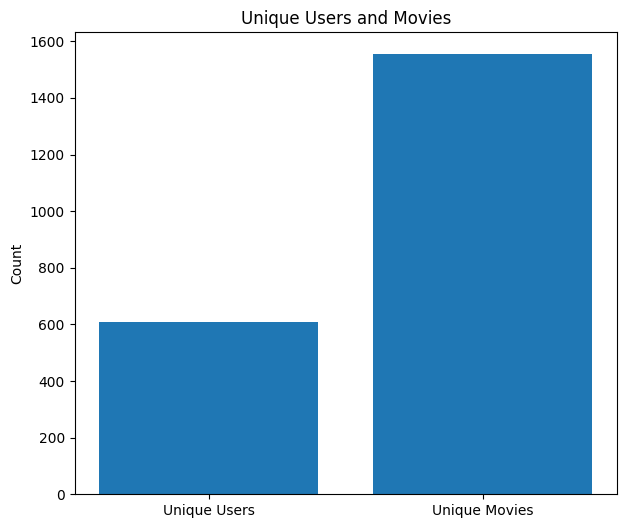

In [ ]:
num_users = merged_clean["userIdrater"].nunique()
print("Unique users:", num_users)
num_movies = merged_clean["movieId"].nunique()
print("Unique movies:", num_movies)

# Create a bar plot for unique users and items
plt.figure(figsize=(7, 6))
plt.bar(["Unique Users", "Unique Movies"], [num_users, num_movies])
plt.ylabel("Count")
plt.title("Unique Users and Movies")
plt.show()

- There are 610 unique users and 1,554 unique movies.

## **2. Ratings**

### **a. Distribution**

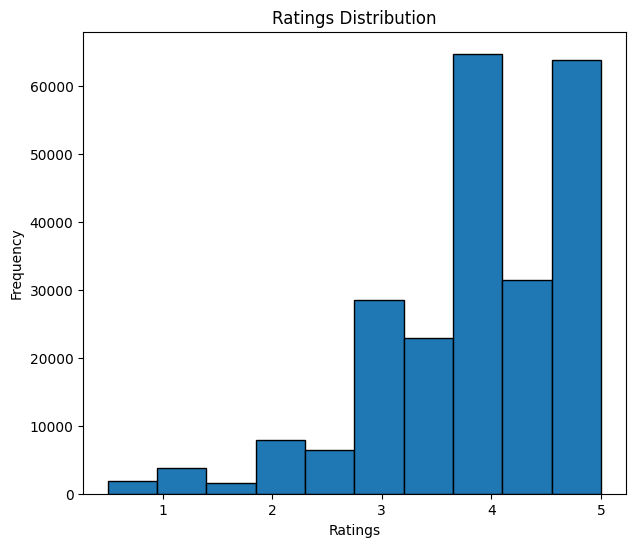

In [ ]:
plt.figure(figsize=(7,6))
plt.hist(merged_clean["rating"], bins=10, edgecolor="black")
plt.xlabel("Ratings")
plt.ylabel("Frequency")
plt.title("Ratings Distribution")
plt.show()

### **c. Average number of ratings per user**

Average number of ratings per user: 382.32


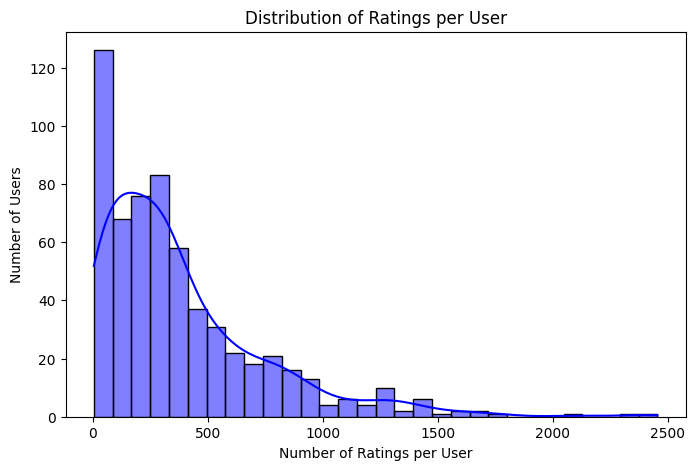

In [ ]:
ratings_per_user = merged_clean.groupby("userIdrater")["rating"].count()
avg_ratings_per_user = ratings_per_user.mean()

print(f"Average number of ratings per user: {avg_ratings_per_user:.2f}")

# Visualizing the distribution of ratings per user
plt.figure(figsize=(8, 5))
sns.histplot(ratings_per_user, bins=30, kde=True, color="blue")
plt.xlabel("Number of Ratings per User")
plt.ylabel("Number of Users")
plt.title("Distribution of Ratings per User");

- Most users gave a rating of 4 and 5.
- The average number of ratings per user is 382.32.

Top 10 users with the most ratings:
 userIdrater
474    2455
414    2343
599    2100
68     1791
610    1701
274    1665
249    1635
448    1575
380    1536
305    1460
Name: rating, dtype: int64

User Ratings Percentiles:
 count     610.000000
mean      382.316393
std       365.395411
min         5.000000
25%       106.500000
50%       280.000000
75%       525.000000
90%       854.200000
95%      1146.150000
99%      1629.600000
max      2455.000000
Name: rating, dtype: float64


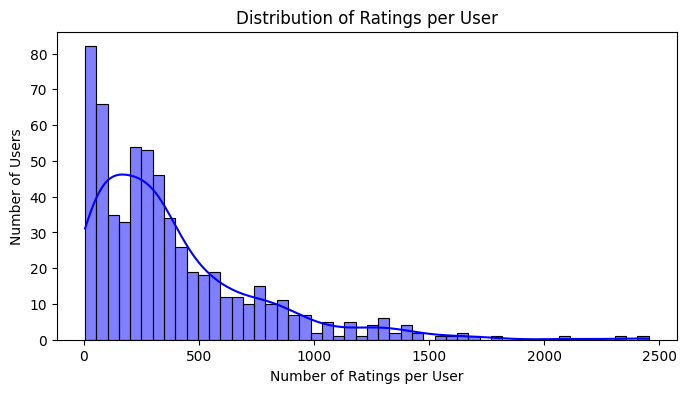

In [ ]:
top_users = ratings_per_user.sort_values(ascending=False).head(10)
print("Top 10 users with the most ratings:\n", top_users)

# Plot distribution of ratings per user
plt.figure(figsize=(8, 4))
sns.histplot(ratings_per_user, bins=50, kde=True, color="blue")
plt.xlabel("Number of Ratings per User")
plt.ylabel("Number of Users")
plt.title("Distribution of Ratings per User");

# user ratings by percentile
percentiles = ratings_per_user.describe(percentiles=[.25, .50, .75, .90, .95, .99])
print("\nUser Ratings Percentiles:\n", percentiles)

**1. Users**
- The most active user (userIdrater = 474) rated 2,455 movies.
- The second most active (userIdrater = 414) rated 2,343 movies.
- Even the 10th most active user rated 1,460 movies.

**2. Average and Distribution of Ratings per User**
- The mean is 382.3, while the median (50th percentile) =is 280. It shows that most users rated fewer movies than the mean suggests.
- The standard deviation of 365.4 is an indication of a large variation in how many movies users rate.

**3. User rating activity**
- The 25th percentile (106.5 ratings) and 75th percentile (525 ratings) show that many users rate relatively few movies.
- The 95th percentile (1,146 ratings) and 99th percentile (1,629 ratings) confirm that a small group of users contributes a huge number of ratings.

These observations and the histogrampoint to highly skewed data where the most active user rated 2,500 movies and the least active user rated 5 movies. It will be important to normalize the ratings to minimize the influence of the active users.

## **3. Categorical Columns**

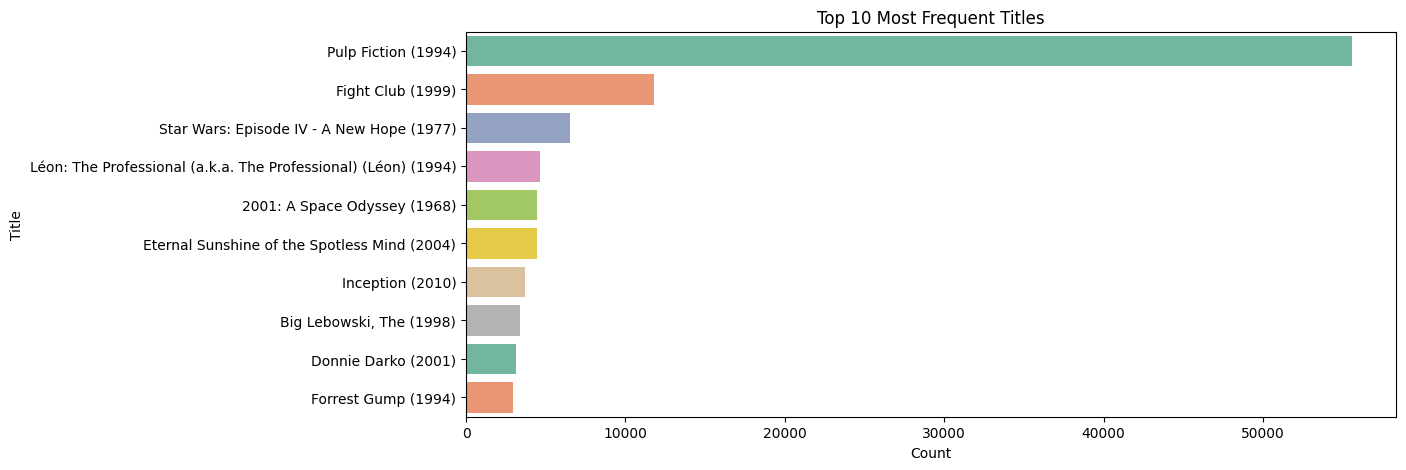

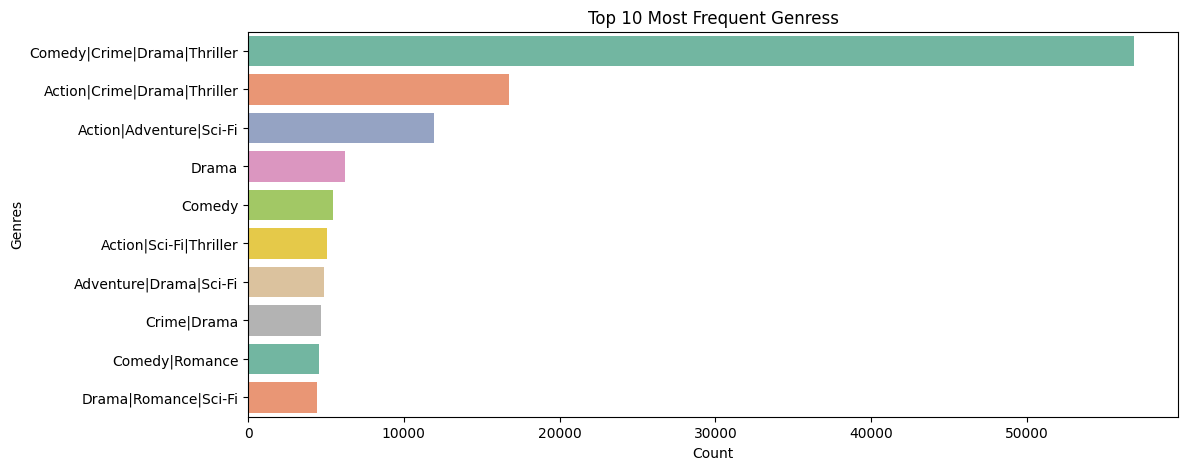

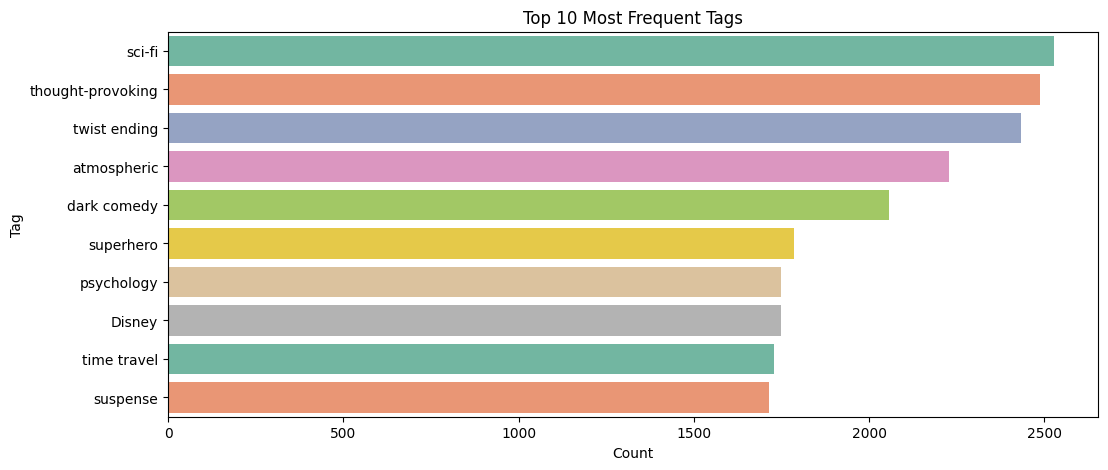

In [ ]:
cat_cols = ["title", "genres", "tag"]
for col in cat_cols:
    plt.figure(figsize=(12, 5))
    sns.barplot(y=merged_clean[col].value_counts().head(10).index,
                x=merged_clean[col].value_counts().head(10).values,
                palette="Set2")
    plt.title(f"Top 10 Most Frequent {col.capitalize()}s")
    plt.xlabel("Count")
    plt.ylabel(col.capitalize())
    plt.show()

- **Pulp Fiction (1994)** was the most popular movie, going by the number of times it was rated in the dataset.
- **Commedy/Crime/Drama/Thriller** was the most frequently reviewed genre.
- **Sci-fi, thought-provoking and twist ending** topped as the most frequent tags.
- A wordcloud can represent the tags popularity better.

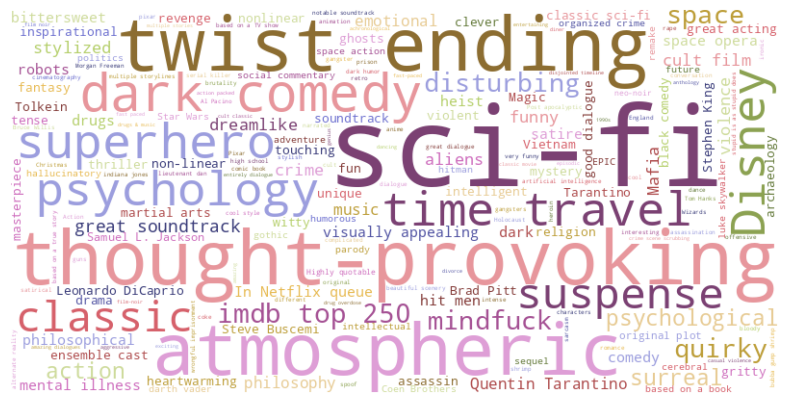

In [ ]:
# tag frequency
tag_counts = merged_clean['tag'].value_counts()

# a dictionary of tag frequencies
tag_frequencies = {tag: count for tag, count in tag_counts.items()}

# WordCloud
wordcloud = WordCloud(width=800, height=400, background_color='white', colormap="tab20b").generate_from_frequencies(tag_frequencies)

plt.figure(figsize=(8, 6))
plt.imshow(wordcloud, interpolation='bilinear')
plt.axis('off')
plt.tight_layout();

### **a. Top 10 Highest Rated Movies**

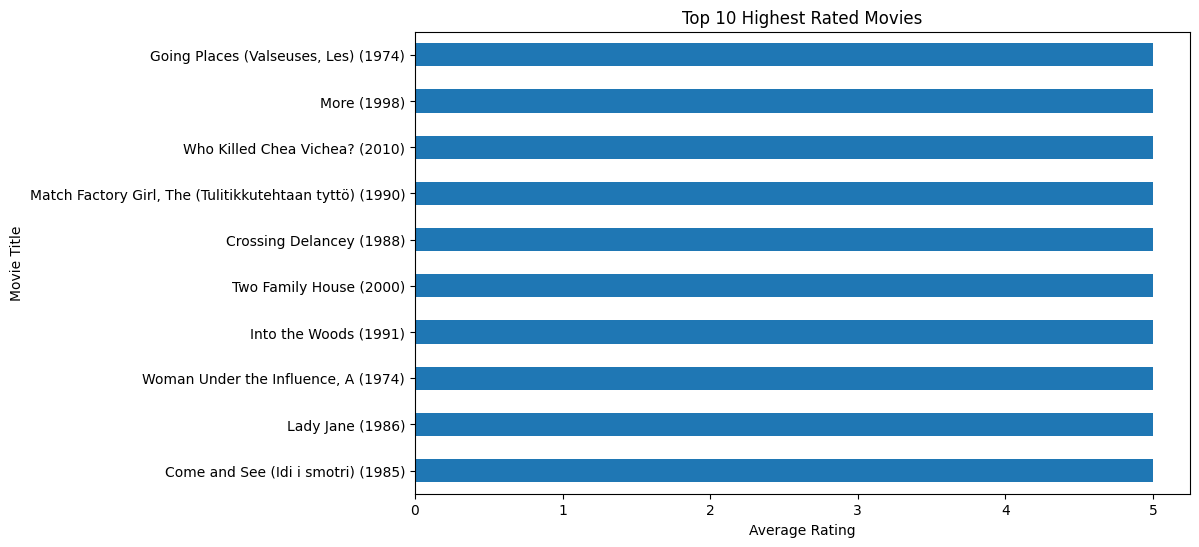

In [ ]:
top_rated_movies = merged_clean.groupby('title')['rating'].mean().sort_values(ascending=False).head(10)
plt.figure(figsize=(10, 6))
top_rated_movies.plot(kind='barh')
plt.title('Top 10 Highest Rated Movies')
plt.xlabel('Average Rating')
plt.ylabel('Movie Title');

### **b. Bottom 10 Lowest Rated Movies**

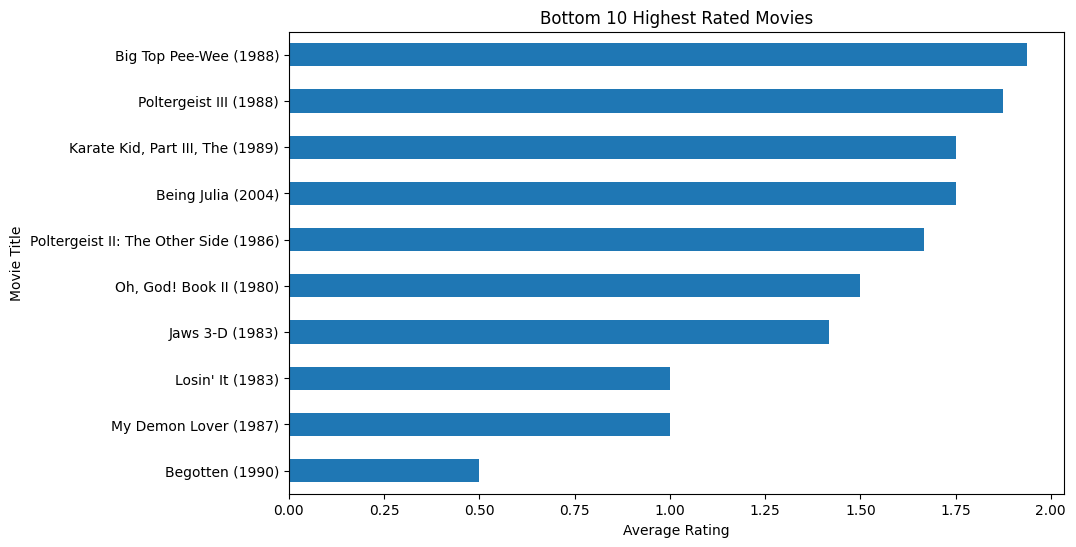

In [ ]:
bottom_rated_movies = merged_clean.groupby('title')['rating'].mean().sort_values(ascending=True).head(10)
plt.figure(figsize=(10, 6))
bottom_rated_movies.plot(kind='barh')
plt.title('Bottom 10 Highest Rated Movies')
plt.xlabel('Average Rating')
plt.ylabel('Movie Title');

### **c. Top 10 Most Common Genres**

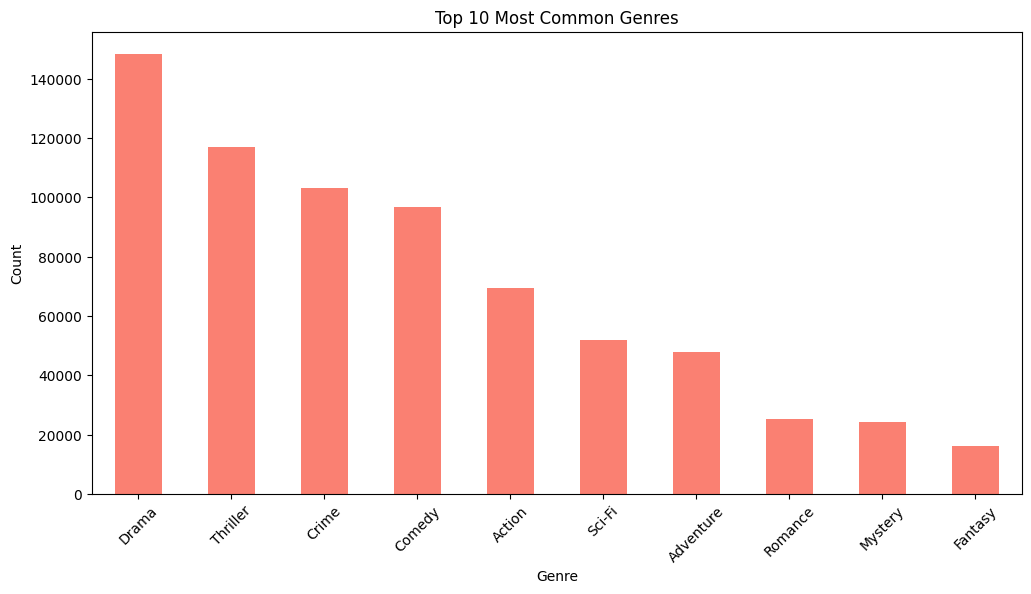

In [ ]:
genre_counts_top = merged_clean['genres'].str.split('|', expand=True).stack().value_counts()
plt.figure(figsize=(12, 6))
genre_counts.head(10).plot(kind='bar', color='salmon')
plt.title('Top 10 Most Common Genres')
plt.xlabel('Genre')
plt.ylabel('Count')
plt.xticks(rotation=45)
plt.show()

### **d. Bottom 10 Least Common Genres**

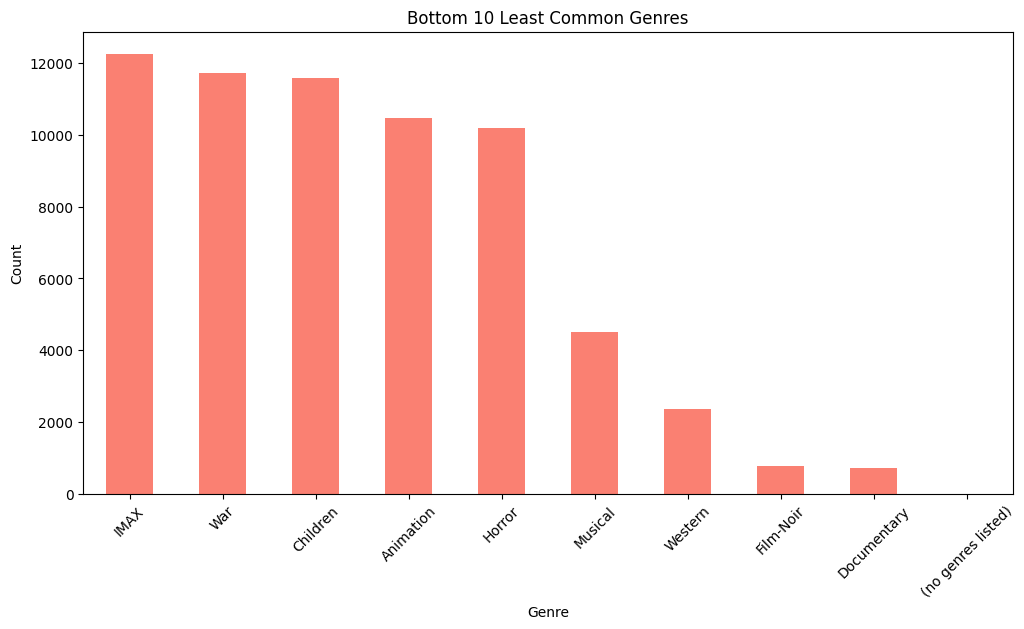

In [ ]:
genre_counts_bottom = merged_clean['genres'].str.split('|', expand=True).stack().value_counts()
plt.figure(figsize=(12, 6))
genre_counts.tail(10).plot(kind='bar', color='salmon')
plt.title('Bottom 10 Least Common Genres')
plt.xlabel('Genre')
plt.ylabel('Count')
plt.xticks(rotation=45)
plt.show()

- The top rated movies all had a rating of 5.
- On genres, **Drama** was the most common in the dataset.

## **4. Time-based Analysis**

In [ ]:
print("Most recent timestamprater:", merged_clean['timestamprater'].max())
print("Oldest timestamprater:", merged_clean['timestamprater'].min())
print("Most recent timestamptag:", merged_clean['timestamptag'].max())
print("Oldest timestamptag:", merged_clean['timestamptag'].min())

Most recent timestamprater: 2018-09-24 14:27:30
Oldest timestamprater: 1996-03-29 18:36:55
Most recent timestamptag: 2018-09-16 11:50:03
Oldest timestamptag: 2006-01-13 19:09:12


- The timestamp features reveal that the data ranges from March 1996 to September 2018.

### **Correlation between the year and its average rating**

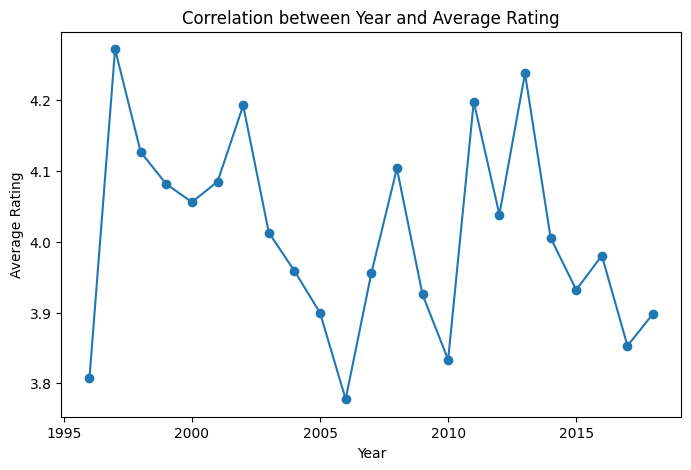

In [ ]:
# Extract the year from the 'timestamprater' column
merged_clean['year'] = merged_clean['timestamprater'].dt.year

# Group by year and calculate the average rating for each year
yearly_avg_ratings = merged_clean.groupby('year')['rating'].mean()

# Create the plot
plt.figure(figsize=(8, 5))
plt.plot(yearly_avg_ratings.index, yearly_avg_ratings.values, marker='o')
plt.xlabel('Year')
plt.ylabel('Average Rating')
plt.title('Correlation between Year and Average Rating');

- Highest movie ratings were made in 1997 while the lowest ratings were in 2006.

# **Modeling**

## **1. Data Preprocessing**
-  The final model is expected to provide top 5 movie recommendations to a user, based on their ratings of other movies. Based on this, the most appropriate columns will be `userIdrater`, `movieId`, `rating`. Other columns will be excluded from the modeling dataset.
- To prevent disproportionate influence by the active users' recommendations/ratings, data will first be checked for sparsity, thennormalized.

### **a. Specifying Columns**

In [ ]:
model_df = merged_clean[['userIdrater', 'movieId', 'rating']]
model_df.head()

,userIdrater,movieId,rating
0,1,1,4.0
1,1,1,4.0
2,1,1,4.0
3,1,3,4.0
4,1,3,4.0


### **b. Data Sparsity**
- Data sparsity occurs when a dataset has a large number of missing values, particularly in user-item interaction matrices.
- Luckily, Collaborative filtering inherently handles sparsity. The dataset will not need to have the missing data imputed/filled.
- However, extremely sparse data might benefit from dimensionality reduction techniques (SVD does this).

In [ ]:
# check sparsity just for knowledge
total_possible_ratings = num_users * num_movies
actual_ratings = model_df.shape[0]

# Calculate missing ratings and sparsity
missing_ratings = total_possible_ratings - actual_ratings
sparsity = (missing_ratings / total_possible_ratings) * 100

print(f"Total possible ratings: {total_possible_ratings}")
print(f"Actual ratings: {actual_ratings}")
print(f"Sparsity of the data: {sparsity:.2f}%")

Total possible ratings: 947940
Actual ratings: 233213
Sparsity of the data: 75.40%


- The dataset is highly sparse; 75.4% of the ratings are missing.
- The model will struggle to make accurate recommendations if not dealt with.

Prepare Data

### **c. Splitting the Data for Training and Testing**
- The data is split before pivoting so that data leakage is minimized by separating train and test sets.

In [ ]:
from sklearn.model_selection import train_test_split

train_df, test_df = train_test_split(model_df_aggregated, test_size=0.2, random_state=42)

In [ ]:
# create user-item interaction matrix for each set
train = train_df.pivot(index='userIdrater', columns='movieId', values='rating')
test = test_df.pivot(index='userIdrater', columns='movieId', values='rating')

In [ ]:
train.columns

Index([     1,      2,      3,      5,      7,     11,     14,     16,     17,
           21,
       ...
       176371, 176419, 179401, 180031, 180985, 183611, 184471, 187593, 187595,
       193565],
      dtype='int64', name='movieId', length=1517)

In [ ]:
test.columns

Index([     1,      2,      3,      5,      7,     11,     14,     16,     17,
           21,
       ...
       167746, 168248, 168252, 174053, 174055, 176371, 176419, 179401, 184471,
       187593],
      dtype='int64', name='movieId', length=1208)

- The test set has less columns (1208 vs 1517 in train set). This should be harmonised.
- The data is then sorted for consistency.

In [ ]:
common_movies = train.columns.intersection(test.columns)
train = train[common_movies]
train = train.sort_index(axis=1)

test = test[common_movies]
test = test.sort_index(axis=1)

In [ ]:
train.columns

Index([     1,      2,      3,      5,      7,     11,     14,     16,     17,
           21,
       ...
       167746, 168248, 168252, 174053, 174055, 176371, 176419, 179401, 184471,
       187593],
      dtype='int64', name='movieId', length=1171)

In [ ]:
test.columns

Index([     1,      2,      3,      5,      7,     11,     14,     16,     17,
           21,
       ...
       167746, 168248, 168252, 174053, 174055, 176371, 176419, 179401, 184471,
       187593],
      dtype='int64', name='movieId', length=1171)

In [ ]:
# Convert the matrix to a sparse format
# fill missing values with 0

train_sparse_matrix = csr_matrix(train.fillna(0)) # train data
test_sparse_matrix = csr_matrix(test.fillna(0)) # test data

## **2. Baseline Model: Singular Value Decomposition (SVD)**

- Further, extract latent factors and make predictions.
- The matrix is decomposed into latent factors, handling sparsity directly, and uncovering hidden patterns in the data.

In [ ]:
# svd model
svd = TruncatedSVD(n_components=50, random_state=42)

In [ ]:
svd_matrix_train = svd.fit_transform(train_sparse_matrix)

# Reconstruct the train interaction matrix
reconstructed_matrix_train = np.dot(svd_matrix_train, svd.components_)

**Model Evaluation**
- Predict on test set.

In [ ]:
# transform test sparse matrix
svd_matrix_test = svd.transform(test_sparse_matrix)

reconstructed_matrix_test = np.dot(svd_matrix_test, svd.components_)

**Metrics**

In [ ]:
# RMSE
mse_test = mean_squared_error(test.fillna(0), reconstructed_matrix_test)
rmse_test = np.sqrt(mse_test)
print(f"Test RMSE: {rmse_test:.4f}")

#MAE
mae_test = mean_absolute_error(test.fillna(0), reconstructed_matrix_test)
print(f"Test MAE: {mae_test:.4f}")

# F1-score
# Convert predictions and actual ratings to binary classifications
threshold = 4 # positive for > 4
y_true = (test.fillna(0) >= threshold).astype(int)
y_pred = (reconstructed_matrix_test >= threshold).astype(int)

f1 = f1_score(y_true.values.flatten(), y_pred.flatten(), average='weighted') # Use 'weighted' for multiclass
print(f"Test F1-score: {f1:.4f}")

Test RMSE: 0.4011
Test MAE: 0.1326
Test F1-score: 0.9881


- Even with the sparsity, the model performed well on the test set with a low RMSE of 0.4011. This indicates that the predicted ratings are fairly accurate.
- The low MAE of 0.1326 is evidence of good performance with less difference between the predicted and actual ratings.
- The F1-score is high (0.9881), revealing that the model is good at predicting ratings above 4, with a good balance between precision (correctly predicting liked ratings) and recall (not missing any liked ratings).
- Overall, the model is performing well at predicting ratings, with a good balance between accuracy and precision.

## **3. Model 2: k-Nearest Neighbors (k-NN)**

In [ ]:
# Define reader and load dataset
reader = Reader(rating_scale=(1, 5))  # Adjust rating scale as needed
data = Dataset.load_from_df(model_df_aggregated[['userIdrater', 'movieId', 'rating']], reader)

In [ ]:
train_data = interaction_matrix_train.stack().reset_index()
train_data.columns = ['userIdrater', 'movieId', 'rating']

test_data = interaction_matrix_test.stack().reset_index()
test_data.columns = ['userIdrater', 'movieId', 'rating']

In [ ]:
data_train = Dataset.load_from_df(train_data, reader)
trainset = data.build_full_trainset()

**Model Evaluation**

In [ ]:
# train model
sim_options = {'name': 'cosine', 'user_based': True}
knn_basic = KNNBasic(sim_options=sim_options)
knn_basic.fit(trainset)

Computing the cosine similarity matrix...
Done computing similarity matrix.


In [ ]:
# predictions
testset = list(test_data.itertuples(index=False, name=None))  # Convert to (userId, movieId, rating)
predictions = knn_basic.test(testset)

# actual vs predictions
y_true = np.array([pred.r_ui for pred in predictions])
y_pred = np.array([pred.est for pred in predictions])

**Metrics**

In [ ]:
rmse = np.sqrt(mean_squared_error(y_true, y_pred))
mae = mean_absolute_error(y_true, y_pred)

# Step 6: Convert to binary classification for Precision, Recall, F1-score
threshold = 4  # Positive class if rating ≥ 4
y_true_binary = (y_true >= threshold).astype(int)
y_pred_binary = (y_pred >= threshold).astype(int)

precision = precision_score(y_true_binary, y_pred_binary)
recall = recall_score(y_true_binary, y_pred_binary)
f1 = f1_score(y_true_binary, y_pred_binary)

# Step 7: Print results
print(f"Test RMSE: {rmse:.4f}")
print(f"Test MAE: {mae:.4f}")
print(f"Test F1-score: {f1:.4f}")

Test RMSE: 0.8291
Test MAE: 0.6294
Test F1-score: 0.6712


The KNNBasic's results are on the higher scale.
- RMSE of 0.83 shows low accuracy in predicting correct ratings.
- MAE of 0.63 shows a significant absolute difference between predicted and actual ratings.
- F1-score at 0.67 says that the model performs poorly in identifying ratings above the set threshold of 4.

## **4. Model 3: Tuning SVD**

In [ ]:
# grid
svd_grid = {'n_components': [50, 100, 200]} # Number of latent factors

tuned_svd = TruncatedSVD(random_state=42)

# gridsearch
from sklearn.model_selection import GridSearchCV
gs = GridSearchCV(tuned_svd, svd_grid,
                  scoring='neg_mean_squared_error', cv=3, n_jobs=-1, verbose=1)

gs.fit(train_sparse_matrix)

# best params
print("Best parameters:", gs.best_params_)
print("Best negative MSE:", gs.best_score_)

Fitting 3 folds for each of 3 candidates, totalling 9 fits
Best parameters: {'n_components': 50}
Best negative MSE: nan


In [ ]:
# best model
best_svd = gs.best_estimator_

# predict on test set
svd_matrix_test = best_svd.transform(test_sparse_matrix)
reconstructed_matrix_test = np.dot(svd_matrix_test, best_svd.components_)

# calculate metrics
# RMSE
mse_test = mean_squared_error(test.fillna(0), reconstructed_matrix_test)
rmse_test = np.sqrt(mse_test)
print(f"Test RMSE (tuned): {rmse_test:.4f}")

# MAE
mae_test = mean_absolute_error(test.fillna(0), reconstructed_matrix_test)
print(f"Test MAE (tuned): {mae_test:.4f}")

# F1-score
threshold = 4 # positive for > 4
y_true_best = (test.fillna(0) >= threshold).astype(int)
y_pred_best = (reconstructed_matrix_test >= threshold).astype(int)

f1 = f1_score(y_true_best.values.flatten(), y_pred_best.flatten(), average='weighted') # Use 'weighted' for multiclass
print(f"Test F1-score (tuned): {f1:.4f}")

Test RMSE (tuned): 0.4011
Test MAE (tuned): 0.1326
Test F1-score (tuned): 0.9881


The results are the same as the baseline SVD model, which means that the initial hyperparameters were optimal.

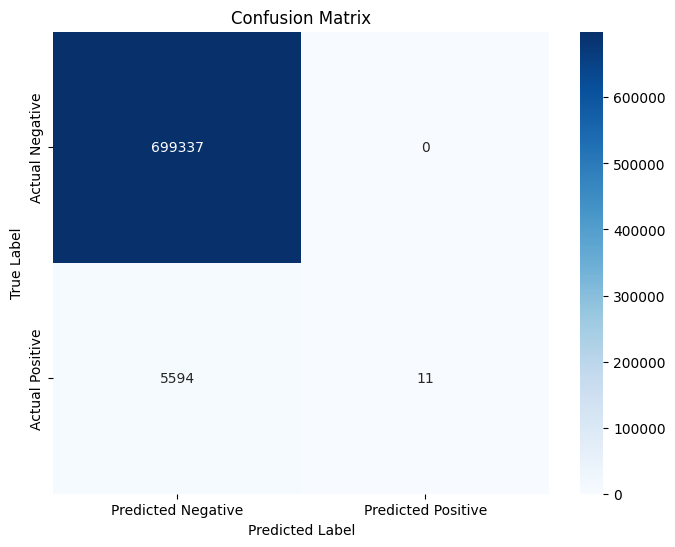

In [ ]:
import matplotlib.pyplot as plt
import seaborn as sns
from sklearn.metrics import confusion_matrix

# Assuming 'test' and 'reconstructed_matrix_test' are defined from previous code
threshold = 4  # Positive class if rating ≥ 4

# Convert predictions and actual ratings to binary classifications
y_true_binary = (test.fillna(0) >= threshold).astype(int)
y_pred_binary = (reconstructed_matrix_test >= threshold).astype(int)

# Convert to NumPy arrays before flattening
cm = confusion_matrix(y_true_binary.to_numpy().flatten(), y_pred_binary.flatten())

plt.figure(figsize=(8, 6))
sns.heatmap(cm, annot=True, fmt="d", cmap="Blues",
            xticklabels=["Predicted Negative", "Predicted Positive"],
            yticklabels=["Actual Negative", "Actual Positive"])
plt.title("Confusion Matrix")
plt.xlabel("Predicted Label")
plt.ylabel("True Label")
plt.show()

- The confusion matrix displays significant **class imbalance**.
- This is expected for many recommendation systems, mostly due to te fact that the model has no direct information on what a user likes or dislikes. Hence, it can only infer a user's preferences from the provided ratings.
- True negatives(699,337) seem accurate given the sparsity of the data. Most user-item pairs do not have an interaction.
- False Negatives (5,594) represent inaccurate non-interactions (ratings) that were actual interactions.
- True Positives are only 11, the model correctly predicted very few ratings as ratings.
- False Positives (0) is a matter of concern. It may be due to biased model performance (towards negatives),

## **Save the Best Model**

In [ ]:
import os
import joblib

model_dir = "model/model"  # Replace with the actual path
model_path = os.path.join(model_dir, "best_svd_model.pkl")

if not os.path.exists(model_dir):
    os.makedirs(model_dir)

# Save the best SVD model
joblib.dump(best_svd, '/model/best_svd_model.pkl')


['/model/best_svd_model.pkl']